In [1]:
from idc_index import IDCClient
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
c = IDCClient()

c.fetch_index('clinical_index')

print('Columns available in clinical_index:\n' + '\n'.join(c.clinical_index.keys()))

2026-02-08 18:55:41,915 - Index clinical_index already installed, loading from C:\Users\sxr4ue\AppData\Local\IDC\idc_index_data\23.4.1\clinical_index.parquet
2026-02-08 18:55:41,946 - Since clinical_index was fetched, also installing corresponding tables.
2026-02-08 18:55:43,538 - IDC clinical data downloaded successfully to C:\Users\sxr4ue\AppData\Local\IDC\IDC\v23\clinical_data


Columns available in clinical_index:
collection_id
table_name
short_table_name
column
column_label
values


In [3]:
# Accessing clinical metadata
nlst_clinical_data_columns = c.clinical_index[c.clinical_index['collection_id'] == 'nlst']
nlst_clinical_data_columns[['short_table_name', 'column', 'column_label', 'values']]

,short_table_name,column,column_label,values
7184,nlst_canc,dicom_patient_id,idc_provenance_dicom_patient_id,[]
7185,nlst_canc,source_batch,idc_provenance_source_batch,"[{'option_code': '0', 'option_description': No..."
7186,nlst_canc,pid,pid,[]
7187,nlst_canc,lc_topog,ICD-O-3 Topography: ICD-O-3 topography of lung...,"[{'option_code': 'C34.0', 'option_description'..."
7188,nlst_canc,topog_source,Source of samples for ICD-O-3 code: Indicates ...,"[{'option_code': '.M', 'option_description': '..."
...,...,...,...,...
7304,nlst_screen,ctdxqual_graininess,Reason for limited / non-diagnostic CT: Excess...,"[{'option_code': '.N', 'option_description': '..."
7305,nlst_screen,ctdxqual_other,Reason for limited / non-diagnostic CT: Other ...,"[{'option_code': '.N', 'option_description': '..."
7306,nlst_screen,ct_recon_filter3,CT reconstruction algorithm / filter: What CT ...,"[{'option_code': '.M', 'option_description': '..."
7307,nlst_screen,ct_recon_filter4,CT reconstruction algorithm / filter: What CT ...,"[{'option_code': '.M', 'option_description': '..."


In [4]:
# Search column names and labels keywords to identify metadata of interest
stage_columns = nlst_clinical_data_columns[nlst_clinical_data_columns['column_label'].str.contains('stage', case=False, na=False)]
stage_columns

,collection_id,table_name,short_table_name,column,column_label,values
7191,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,de_stag,"Stage (""Best"": Path if avail., else Clin): Lun...","[{'option_code': '.M', 'option_description': '..."
7192,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,path_stag,Pathologic Stage: Pathologic stage of lung can...,"[{'option_code': '.M', 'option_description': '..."
7193,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,clinical_stag,Clinical Stage: Clinical stage of lung cancer ...,"[{'option_code': '.M', 'option_description': '..."
7194,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,stage_sum,Summary staging: Summary staging.For all ACRIN...,"[{'option_code': '.M', 'option_description': '..."
7195,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,valcsg,VALCSG Stage (Small cell only): VALCSG staging...,"[{'option_code': '.M', 'option_description': '..."
7202,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,de_stag_7thed,AJCC 7th edition stage: Stage of first primary...,"[{'option_code': '.M', 'option_description': '..."
7208,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,source_best_stage,"Source of ""best"" stage (de_stag): Describes wh...","[{'option_code': '1', 'option_description': 'P..."
7215,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,stage_only,"Stage Only (if separate T, N, & M not availabl...","[{'option_code': '.M', 'option_description': '..."
7269,nlst,bigquery-public-data.idc_v23_clinical.nlst_prsn,nlst_prsn,de_stag,"Lung cancer Stage: Lung cancer stage (AJCC 6),...","[{'option_code': '.M', 'option_description': '..."
7286,nlst,bigquery-public-data.idc_v23_clinical.nlst_prsn,nlst_prsn,de_stag_7thed,AJCC 7th edition stage: Stage of first primary...,"[{'option_code': '.M', 'option_description': '..."


In [5]:
# Access nlst_canc table
nlst_canc_df = c.get_clinical_table("nlst_canc")
nlst_canc_df

,dicom_patient_id,source_batch,pid,lc_topog,topog_source,de_type,de_grade,de_stag,path_stag,clinical_stag,...,path_t,clinical_n,path_n,clinical_m,path_m,stage_only,study_yr,dataset_version,lc_order,candx_days
0,102266,0,102266,C34.1,,8046,4,110,,,...,,,,,,110,0,2011.02.03/05.12.21,1,69
1,118193,0,118193,C34.9,4,,1,888,,,...,,,,,,888,0,2011.02.03/05.12.21,1,128
2,119813,0,119813,C34.9,1,8046,8,888,,,...,,,,,,888,0,2011.02.03/05.12.21,1,18
3,125998,0,125998,C34.2,2,8046,8,,,,...,,,,,,,0,2011.02.03/05.12.21,1,212
4,102161,0,102161,C34.1,,8013,4,110,110,,...,100,,0,,0,110,0,2011.02.03/05.12.21,1,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2145,210195,0,210195,C34.2,1,8070,4,900,999,999,...,999,0,,0,,,5,2011.02.03/05.12.21,2,1957
2146,210218,0,210218,C34.2,,8240,9,999,999,999,...,999,999,999,999,999,,2,2011.02.03/05.12.21,1,1024
2147,213639,0,213639,C34.3,3,8046,4,400,999,999,...,999,200,999,0,999,400,1,2011.02.03/05.12.21,1,721
2148,214850,0,214850,C34.8,2,8041,5,999,999,999,...,999,100,999,0,999,,4,2011.02.03/05.12.21,1,1751


In [6]:
# What are values of attribute clinical_stag?
print(nlst_canc_df['clinical_stag'].unique())

# Make them human readable
clinical_stag_values = nlst_clinical_data_columns[nlst_clinical_data_columns['column']=='clinical_stag']['values'].values[0]
print(clinical_stag_values)

['' '110' '120' '210' '220' '310' '320' '400' '888' '900' '994' '999']
[{'option_code': '.M', 'option_description': 'Missing'}
 {'option_code': '110', 'option_description': 'Stage IA'}
 {'option_code': '120', 'option_description': 'Stage IB'}
 {'option_code': '210', 'option_description': 'Stage IIA'}
 {'option_code': '220', 'option_description': 'Stage IIB'}
 {'option_code': '310', 'option_description': 'Stage IIIA'}
 {'option_code': '320', 'option_description': 'Stage IIIB'}
 {'option_code': '400', 'option_description': 'Stage IV'}
 {'option_code': '888', 'option_description': 'TNM not available'}
 {'option_code': '900', 'option_description': 'Occult Carcinoma'}
 {'option_code': '994', 'option_description': 'Carcinoid, cannot be assessed'}
 {'option_code': '999', 'option_description': 'Unknown, cannot be assessed'}]


In [7]:
# First, create a dictionary from the array of dictionaries
mapping_dict = {item['option_code']: item['option_description'] for item in clinical_stag_values}

# Create the new column 'X_descriptions' using map function
nlst_canc_df['clinical_stag_meaning'] = nlst_canc_df['clinical_stag'].astype(str).map(mapping_dict)

In [8]:
# drop cases that don't have images
with_images = pd.merge(c.index[c.index['Modality'] == 'CT'][['PatientID']].drop_duplicates(), nlst_canc_df, left_on='PatientID', right_on='dicom_patient_id', how='inner')

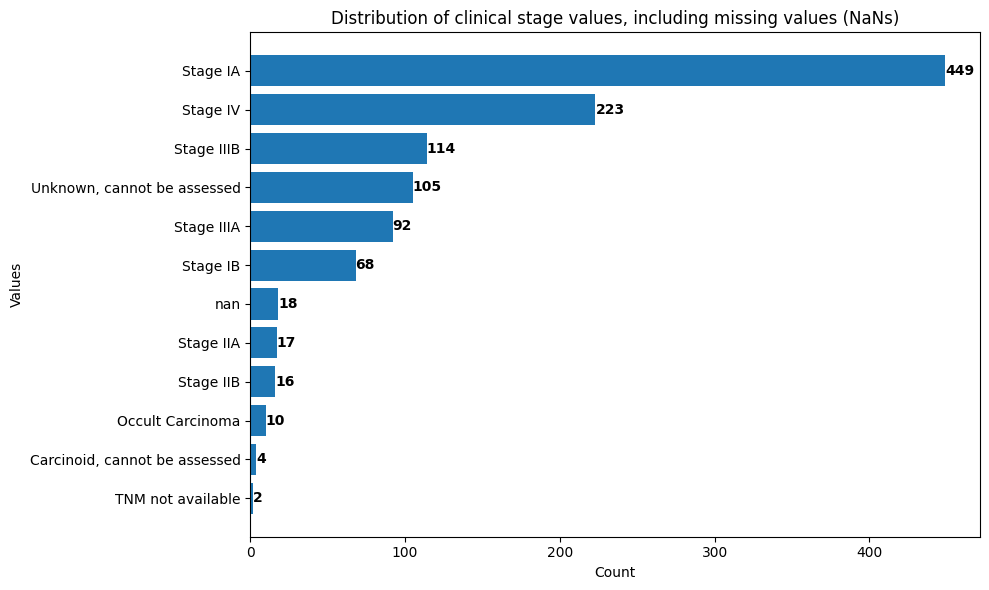

In [9]:
# plot histogram of values in nlst_clinical_df['clinical_stag_meaning'] by count,
# including NaN as a separate item

# Assuming your DataFrame is named 'df' and the column is named 'column_name'

# Count values including NaNs
value_counts = with_images['clinical_stag_meaning'].value_counts(dropna=False)

# Create horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(value_counts.index.astype(str), value_counts.values)

# Add labels to the bars
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f'{width}',
            ha='left', va='center', fontweight='bold')

# Customize the plot
plt.title('Distribution of clinical stage values, including missing values (NaNs)')
plt.xlabel('Count')
plt.ylabel('Values')

# Adjust layout and display the plot
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

In [10]:
print(f'Attributes in IDC index: \n{c.index.dtypes}\n')

Attributes in IDC index: 
collection_id             object
analysis_result_id        object
PatientID                 object
SeriesInstanceUID         object
StudyInstanceUID          object
source_DOI                object
PatientAge                object
PatientSex                object
StudyDate                 object
StudyDescription          object
BodyPartExamined          object
Modality                  object
Manufacturer              object
ManufacturerModelName     object
SeriesDate                object
SeriesDescription         object
SeriesNumber              object
instanceCount              Int64
license_short_name        object
aws_bucket                object
crdc_series_uuid          object
series_aws_url            object
series_size_MB           float64
dtype: object



In [11]:
my_ProjectID = "nlst-radiomics"

import os
os.environ["GCP_PROJECT_ID"] = my_ProjectID

from google.colab import auth
auth.authenticaate_user()

ModuleNotFoundError: No module named 'google.colab'